## Importing Library

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.10.0


### Data Preprocessing

In [11]:
# Set dataset paths
train_dir = 'train'
valid_dir = 'valid'

# Define parameters
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Load datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
    seed=42
)

# Get class names and number of classes
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")

Found 20789 files belonging to 11 classes.
Found 5198 files belonging to 11 classes.
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 11


In [12]:
# Preprocessing function for ResNet50
def preprocess_data(image, label):
    # ResNet50 expects values in range [-1, 1]
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

# Apply preprocessing
train_dataset = train_dataset.map(preprocess_data)
valid_dataset = valid_dataset.map(preprocess_data)

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)

print("Data preprocessing completed!")

Data preprocessing completed!


#### Build ResNet50 Model

In [14]:
# Load pre-trained ResNet50 base model
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg'
)

# Freeze the base model
base_model.trainable = False

print(f"Base model has {len(base_model.layers)} layers")
print(f"Base model output shape: {base_model.output.shape}")

Base model has 176 layers
Base model output shape: (None, 2048)


In [15]:
# Build the complete model
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(256, activation='relu', name='dense_1'),
    tf.keras.layers.Dropout(0.5, name='dropout'),
    tf.keras.layers.Dense(num_classes, activation='softmax', name='predictions')
])

# Display model summary
model.build((None, 224, 224, 3))
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense_1 (Dense)             (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 predictions (Dense)         (None, 11)                2827      
                                                                 
Total params: 24,115,083
Trainable params: 527,371
Non-trainable params: 23,587,712
_________________________________________________________________
None


### Compile Model

In [16]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


### Train Model

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Train the model
EPOCHS = 10

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=valid_dataset,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed!")

Epoch 1/10
650/650 [==============================] - 1966s 3s/step - loss: 0.4628 - accuracy: 0.8609 - val_loss: 0.0977 - val_accuracy: 0.9717 - lr: 1.0000e-04
Epoch 2/10
650/650 [==============================] - 2134s 3s/step - loss: 0.1141 - accuracy: 0.9662 - val_loss: 0.0604 - val_accuracy: 0.9806 - lr: 1.0000e-04
Epoch 3/10
650/650 [==============================] - 2115s 3s/step - loss: 0.0726 - accuracy: 0.9772 - val_loss: 0.0475 - val_accuracy: 0.9838 - lr: 1.0000e-04
Epoch 4/10
650/650 [==============================] - 1908s 3s/step - loss: 0.0546 - accuracy: 0.9838 - val_loss: 0.0395 - val_accuracy: 0.9848 - lr: 1.0000e-04
Epoch 5/10
650/650 [==============================] - 1549s 2s/step - loss: 0.0425 - accuracy: 0.9876 - val_loss: 0.0382 - val_accuracy: 0.9860 - lr: 1.0000e-04
Epoch 6/10
650/650 [==============================] - 1539s 2s/step - loss: 0.0343 - accuracy: 0.9901 - val_loss: 0.0336 - val_accuracy: 0.9873 - lr: 1.0000e-04
Epoch 7/10
650/650 [==============

#### Saving the Model

In [20]:
# Save the trained model
model_path = 'resnet50_model.keras'
model.save(model_path)
print(f"Model saved as: {model_path}")

# Verify model size
model_size = os.path.getsize(model_path) / (1024 * 1024)  # Size in MB
print(f"Model size: {model_size:.2f} MB")

Model saved as: resnet50_model.keras
Model size: 96.34 MB


In [21]:
# Test loading the saved model
loaded_model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")

# Verify the loaded model works
test_loss, test_accuracy = loaded_model.evaluate(valid_dataset, verbose=0)
print(f"Loaded model validation accuracy: {test_accuracy:.4f}")

Model loaded successfully!
Loaded model validation accuracy: 0.9886


#### Model Summary

In [22]:
print("=" * 60)
print("RESNET50 PLANT DISEASE CLASSIFICATION - SUMMARY")
print("=" * 60)
print(f"Dataset Classes: {len(class_names)}")
print(f"Base Model: ResNet50 (ImageNet pretrained)")
print(f"Input Shape: {IMAGE_SIZE} + (3,)")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Training Epochs: {len(history.history['accuracy'])}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Model Size: {model_size:.2f} MB")
print("=" * 60)

RESNET50 PLANT DISEASE CLASSIFICATION - SUMMARY
Dataset Classes: 11
Base Model: ResNet50 (ImageNet pretrained)
Input Shape: (224, 224) + (3,)
Batch Size: 32
Training Epochs: 10
Final Validation Accuracy: 0.9886
Model Size: 96.34 MB


#### Recording History in JSON

In [23]:
import json

# Save training history to JSON file
history_dict = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}

with open('training_RESNET50_history.json', 'w') as f:
    json.dump(history_dict, f, indent=4)

print("Training history saved to training_RESNET50_history.json")

Training history saved to training_RESNET50_history.json


#### Accuracy Visualization

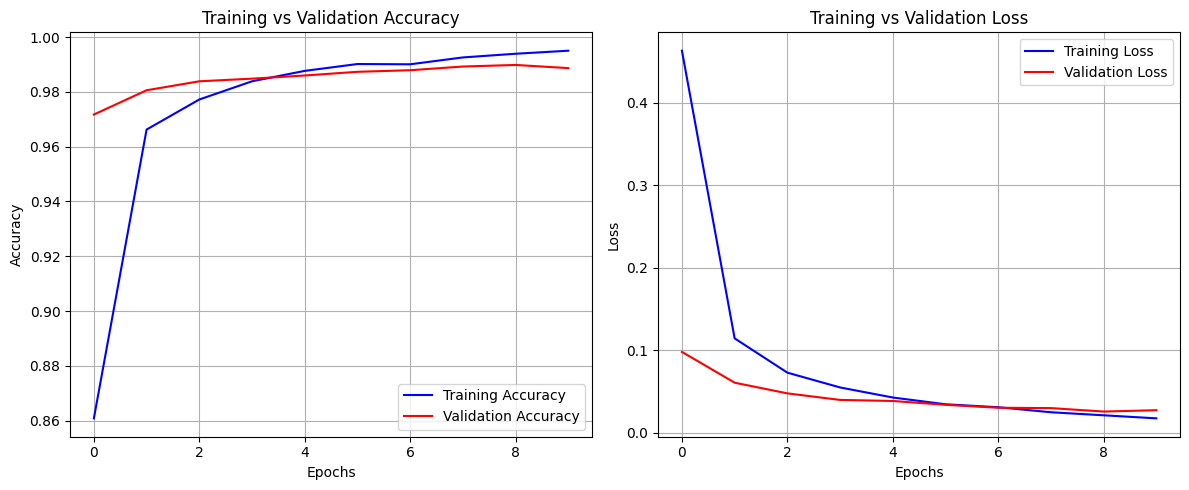

In [24]:
# Create accuracy and loss plots
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-', label='Training Loss')
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Classification Report

In [27]:
# Print detailed classification report
print("Classification Report:")
print("=" * 60)
report = classification_report(y_true_new, y_pred_new, 
                             target_names=class_names, 
                             digits=4)
print(report)
print("=" * 60)

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9980    0.9921    0.9950       504
                                 Apple___Black_rot     0.9980    1.0000    0.9990       497
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000       440
                                   Apple___healthy     0.9941    1.0000    0.9970       502
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9740    0.9122    0.9421       410
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       477
               Corn_(maize)___Northern_Leaf_Blight     0.9303    0.9790    0.9540       477
                            Corn_(maize)___healthy     1.0000    1.0000    1.0000       465
                             Potato___Early_blight     0.9959    1.0000    0.9979       485
                              Potato___Late_blight     1